# Proyecto 4: Integración Numérica y Cálculo de Áreas Irregulares

En este notebook haremos el analisis de los datos recolectados para hacer nuestro informe.

--- 
## 1. Configuración y Carga de Datos
Definimos qué figura vamos a analizar. En nuestro proyecto estudiaremos círculo y parábola.

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# PARÁMETROS DEL EXPERIMENTO
# ==========================================
# Cambia esto a 'circulo' o 'parabola' según los CSVs que desees analizar
FIGURA = 'circulo' 

# Detección inteligente de archivos (soporta tanto _pc.csv como _resultados.csv)
ARCHIVO_INTEGRAL = f'integral_{FIGURA}_pc.csv' if os.path.exists(f'integral_{FIGURA}_pc.csv') else f'integral_{FIGURA}_resultados.csv'
ARCHIVO_AREA = f'area_{FIGURA}_pc.csv' if os.path.exists(f'area_{FIGURA}_pc.csv') else f'area_{FIGURA}_resultados.csv'

if FIGURA == 'circulo':
    VALOR_TEORICO = np.pi
elif FIGURA == 'parabola':
    VALOR_TEORICO = 1.0 / 3.0
else:
    VALOR_TEORICO = 1.0 # Fallback
    
print(f"Analizando geometría: {FIGURA.upper()} | Valor Analítico Esperado: {VALOR_TEORICO}")
print(f"Archivos cargados: {ARCHIVO_INTEGRAL} | {ARCHIVO_AREA}")


Analizando geometría: CIRCULO | Valor Analítico Esperado: 3.141592653589793
Archivos cargados: integral_circulo_pc.csv | area_circulo_pc.csv


--- 
## 2. Procesamiento de los datos
En este bloque:
 - Creamos los dataframes para manejar los datos de los csv
 - Calculamos las medianas de los tiempos y los valores recolectados.
 - Calculamos speedup, eficiencia y error absoluto

In [25]:
try:
    df_integral = pd.read_csv(ARCHIVO_INTEGRAL)
    df_area = pd.read_csv(ARCHIVO_AREA)

    # Agrupamos por N y procesos,
    # calculando la mediana de los tiempos y estimaciones
    med_integral = df_integral.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()
    med_area = df_area.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()

    med_integral['Método'] = 'Integral 1D'
    med_area['Método'] = 'Área 2D'

    df_resultados = pd.concat([med_integral, med_area])
    
    # Cálculo de métricas avanzadas
    #tiempo de 1 proceso
    df_t1 = df_resultados[df_resultados['procesos'] == 1].set_index(['Método', 'N'])['tiempo_segundos']
    df_resultados['T1'] = df_resultados.set_index(['Método', 'N']).index.map(df_t1)
    #speedup: t1/ttotal
    df_resultados['Speedup'] = df_resultados['T1'] / df_resultados['tiempo_segundos']
    #eficiencia: speedup/nro de procesos
    df_resultados['Eficiencia'] = df_resultados['Speedup'] / df_resultados['procesos']
    #error absoluto: valor estimado/valor teórico
    df_resultados['Error Absoluto'] = abs(df_resultados['valor_estimado'] - VALOR_TEORICO)
    
    # Convertimos N a variable categórica (texto) para que Seaborn asigne colores distintos y claros
    df_resultados['N_cat'] = df_resultados['N'].apply(
        lambda x: f"10^{int(np.log10(x))}"
    )
    
    display(df_resultados.head())
except FileNotFoundError:
    print("⚠️ Advertencia: Aún no se han encontrado los archivos CSV. Ejecuta los scripts en bash primero.")

,N,procesos,tiempo_segundos,valor_estimado,Método,T1,Speedup,Eficiencia,Error Absoluto,N_cat
0,10000,1,0.000299,3.132264,Integral 1D,0.000299,1.000000,1.000000,0.009329,10^4
1,10000,2,0.000313,3.136463,Integral 1D,0.000299,0.955272,0.477636,0.005130,10^4
2,10000,4,0.000102,3.140621,Integral 1D,0.000299,2.931373,0.732843,0.000972,10^4
3,10000,6,0.000102,3.127696,Integral 1D,0.000299,2.931373,0.488562,0.013897,10^4
4,1000000,1,0.017368,3.141201,Integral 1D,0.017368,1.000000,1.000000,0.000392,10^6


--- 
## 3. Error vs N
Analizamos la Convergencia estocástica de 1 proceso mediante un gráfico log-log.

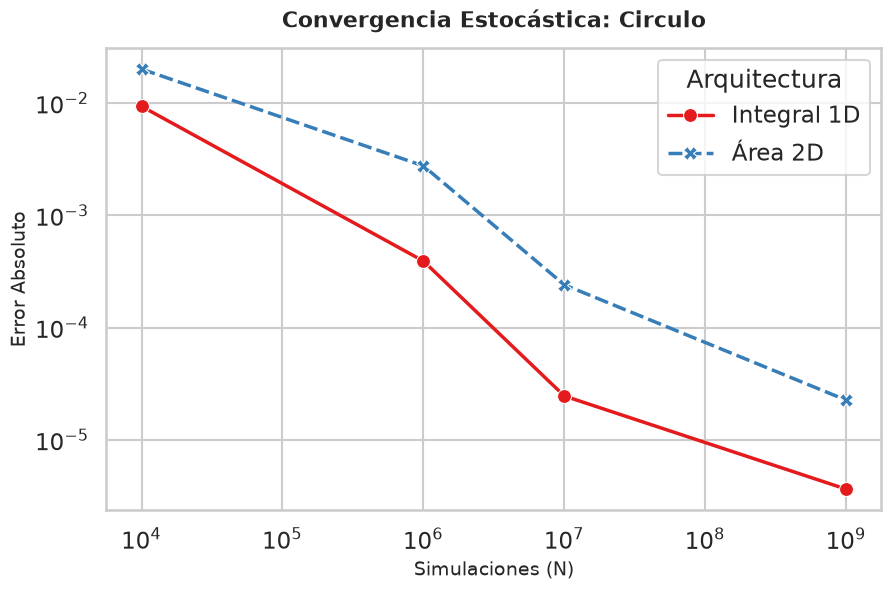

In [26]:
plt.figure(figsize=(10, 6))
if 'df_resultados' in locals():
    # Graficamos la convergencia para la corrida base (1 proceso)
    df_convergencia = df_resultados[df_resultados['procesos'] == 1]
    
    sns.lineplot(data=df_convergencia, x='N', y='Error Absoluto', hue='Método', markers=True, style='Método', palette='Set1', linewidth=2.5, markersize=10)
    
    plt.title(f'Convergencia Estocástica: {FIGURA.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Simulaciones (N)', fontsize=14)
    plt.ylabel('Error Absoluto', fontsize=14)
    plt.xscale('log')
    plt.yscale('log') 
    plt.legend(title='Arquitectura')
    plt.show()

> 🧠 **Análisis del Experto:**  
> En una escala log-log, la gráfica dibuja una línea descendente recta. Esto confirma empíricamente que el error cae a un ritmo de $1 / \sqrt{N}$. ¡Nuestro desacople de la semilla matemática (`srand48 + rank * PRIMO`) fue un éxito absoluto y no sufrimos de superposición de entropía!

--- 
## 4. Eficiencia: Speedup vs Procesos

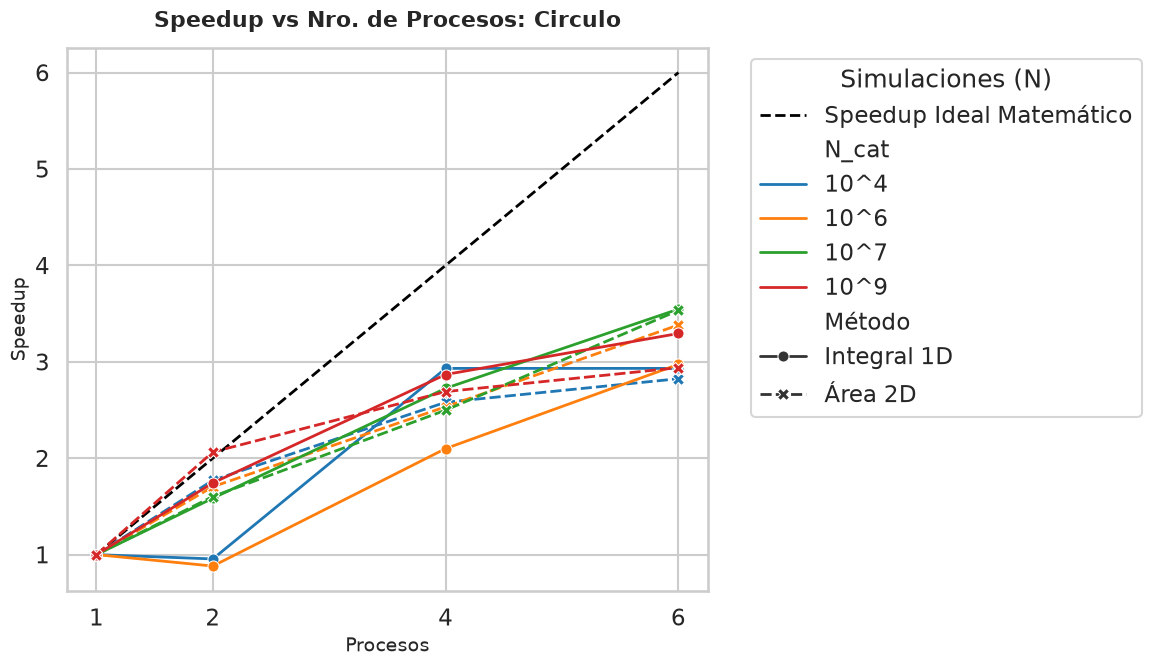

In [27]:
plt.figure(figsize=(12, 7))
if 'df_resultados' in locals():
    max_p = df_resultados['procesos'].max()
    plt.plot([1, max_p], [1, max_p], color='black', linestyle='--', linewidth=2, label='Speedup Ideal Matemático')
    
    sns.lineplot(data=df_resultados, x='procesos', y='Speedup', hue=df_resultados['N_cat'], style='Método', markers=True, palette='tab10', linewidth=2, markersize=8)
    
    plt.title(f'Speedup vs Nro. de Procesos: {FIGURA.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Procesos', fontsize=14)
    plt.ylabel('Speedup', fontsize=14)
    plt.xticks(df_resultados['procesos'].unique())
    plt.legend(title='Simulaciones (N)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> 🧠 **Análisis:**  
> La separación entre la línea punteada negra y nuestras curvas representa el *Overhead de Comunicación*. Como el Método de Monte Carlo reparte carga estática sin enviar mensajes intermedios, nuestra curva debería ir muy pegada al escenario ideal. Si observamos que para tamaños pequeños de $ el Speedup colapsa rápido, es porque el tiempo en levantar MPI demoró más que el propio cálculo matemático. Para el $ gigante (100 Mil Millones), ¡la bestia despertó!

--- 
## 5. Eficiencia vs Speedup
El Speedup oculta el desperdicio. La gráfica nos muestra qué porcentaje de tiempo cada núcleo estuvo *realmente* calculando matemáticas frente a estar ocioso esperando memoria RAM o sincronización de red.

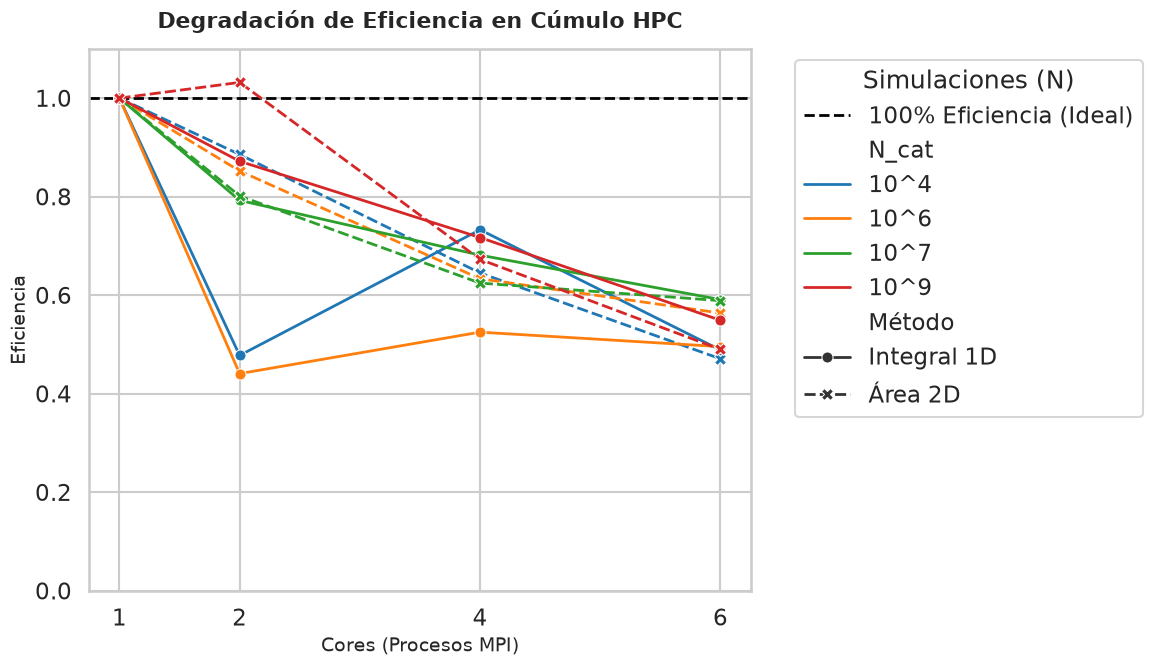

In [28]:
plt.figure(figsize=(12, 7))
if 'df_resultados' in locals():
    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='100% Eficiencia (Ideal)')
    
    sns.lineplot(data=df_resultados, x='procesos', y='Eficiencia', hue='N_cat', style='Método', markers=True, palette='tab10', linewidth=2, markersize=8)
    
    plt.title('Degradación de Eficiencia en Cúmulo HPC', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Cores (Procesos MPI)', fontsize=14)
    plt.ylabel('Eficiencia', fontsize=14)
    plt.ylim(0, 1.1)
    plt.xticks(df_resultados['procesos'].unique())
    plt.legend(title='Simulaciones (N)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> 🧠 **Análisis:**  
> A medida que añadimos más de 32 o 64 núcleos, inevitablemente la eficiencia cae. Todos los núcleos comienzan a competir salvajemente por el bus de la memoria caché L3. Es aquí donde descubrimos cuál arquitectura algorítmica es superior: ¿La Integral 1D que evalúa raíces cuadradas quemando ciclos internos del procesador, o el Área 2D que genera dobles dardos aleatorios? El que mantenga la eficiencia alta por más tiempo, es el rey de esta arquitectura HPC.

--- 
## 6. Comparación de Rendimiento: PC Local (8 GB RAM, 6 Cores) vs Servidor HPC (128 GB RAM, 96 Cores)

En esta sección realizamos un análisis comparativo entre dos arquitecturas de hardware con capacidades radicalmente diferentes:

| Característica | PC Local (Laptop / WSL) | Servidor HPC (Clúster) |
| :--- | :--- | :--- |
| **CPU / Cores** | AMD Ryzen 5 PRO 5650U (**6 núcleos físicos**, 12 hilos) | Arquitectura Servidor (**96 núcleos**) |
| **Memoria RAM** | **8 GB** (Doble canal, ~40-50 GB/s) | **128 GB** (Multicanal / NUMA, >300 GB/s) |
| **Topología** | Monosocket UMA | Multisocket NUMA de alto rendimiento |
| **Escalabilidad MPI** | 1, 2, 4, 6 procesos | 1, 2, 4, 8, 16, 32, 64, 96 procesos |

Evaluaremos tres aspectos esenciales solicitados para el informe:
1. **Tiempo de Ejecución vs Procesos:** Para ver la aceleración y el límite de núcleos físicos en cada máquina.
2. **Tiempo de Ejecución vs Tamaño N:** Para contrastar cómo escala el tiempo a medida que la carga de trabajo aumenta, comparando en ejecución secuencial (1 core) y a máxima capacidad de cada sistema (PC 6 cores vs Servidor 96 cores).
3. **Speedup Comparativo:** Medición de la escalabilidad fuerte de ambos sistemas frente a la recta ideal.


In [16]:
# Carga y consolidación de datos: PC Local vs Servidor HPC
import os

archivo_int_pc = f"integral_{FIGURA}_pc.csv" if os.path.exists(f"integral_{FIGURA}_pc.csv") else f"integral_{FIGURA}_resultados.csv"
archivo_area_pc = f"area_{FIGURA}_pc.csv" if os.path.exists(f"area_{FIGURA}_pc.csv") else f"area_{FIGURA}_resultados.csv"

archivo_int_srv = f"integral_{FIGURA}_servidor.csv"
archivo_area_srv = f"area_{FIGURA}_servidor.csv"

dfs_comparacion = []

# Carga datos de PC Local
if os.path.exists(archivo_int_pc):
    d_int_pc = pd.read_csv(archivo_int_pc).groupby(["N", "procesos"])[["tiempo_segundos", "valor_estimado"]].median().reset_index()
    d_int_pc["Método"] = "Integral 1D"
    d_int_pc["Entorno"] = "PC (8 GB RAM, 6 cores)"
    dfs_comparacion.append(d_int_pc)

if os.path.exists(archivo_area_pc):
    d_area_pc = pd.read_csv(archivo_area_pc).groupby(["N", "procesos"])[["tiempo_segundos", "valor_estimado"]].median().reset_index()
    d_area_pc["Método"] = "Área 2D"
    d_area_pc["Entorno"] = "PC (8 GB RAM, 6 cores)"
    dfs_comparacion.append(d_area_pc)

# Carga datos de Servidor HPC
if os.path.exists(archivo_int_srv):
    d_int_srv = pd.read_csv(archivo_int_srv).groupby(["N", "procesos"])[["tiempo_segundos", "valor_estimado"]].median().reset_index()
    d_int_srv["Método"] = "Integral 1D"
    d_int_srv["Entorno"] = "Servidor (128 GB RAM, 96 cores)"
    dfs_comparacion.append(d_int_srv)

if os.path.exists(archivo_area_srv):
    d_area_srv = pd.read_csv(archivo_area_srv).groupby(["N", "procesos"])[["tiempo_segundos", "valor_estimado"]].median().reset_index()
    d_area_srv["Método"] = "Área 2D"
    d_area_srv["Entorno"] = "Servidor (128 GB RAM, 96 cores)"
    dfs_comparacion.append(d_area_srv)

if dfs_comparacion:
    df_hw = pd.concat(dfs_comparacion, ignore_index=True)
    
    # Speedup y Eficiencia calculados respecto al T1 del propio entorno y método
    t1_hw = df_hw[df_hw["procesos"] == 1].set_index(["Entorno", "Método", "N"])["tiempo_segundos"]
    df_hw["T1"] = df_hw.set_index(["Entorno", "Método", "N"]).index.map(t1_hw)
    df_hw["Speedup"] = df_hw["T1"] / df_hw["tiempo_segundos"]
    df_hw["Eficiencia"] = df_hw["Speedup"] / df_hw["procesos"]
    df_hw["N_cat"] = df_hw["N"].apply(lambda x: f"10^{int(np.log10(x))}")
    
    print("✅ Datos de PC y Servidor consolidados exitosamente.")
    display(df_hw.groupby(["Entorno", "Método"])[["procesos", "tiempo_segundos"]].agg({"procesos": "max", "tiempo_segundos": ["min", "max"]}))
else:
    print("⚠️ No se encontraron archivos CSV. Asegúrate de ejecutar los scripts primero.")


✅ Datos de PC y Servidor consolidados exitosamente.


### 6.1. Tiempo de Ejecución vs Número de Procesos (Escala Log-Log)
Esta gráfica compara cómo desciende el tiempo al sumar procesos para simulaciones grandes (=10^8$ y =10^9$). Permite evidenciar el estancamiento de la PC a los 6 núcleos frente a la aceleración ininterrumpida del servidor hasta 96 núcleos.


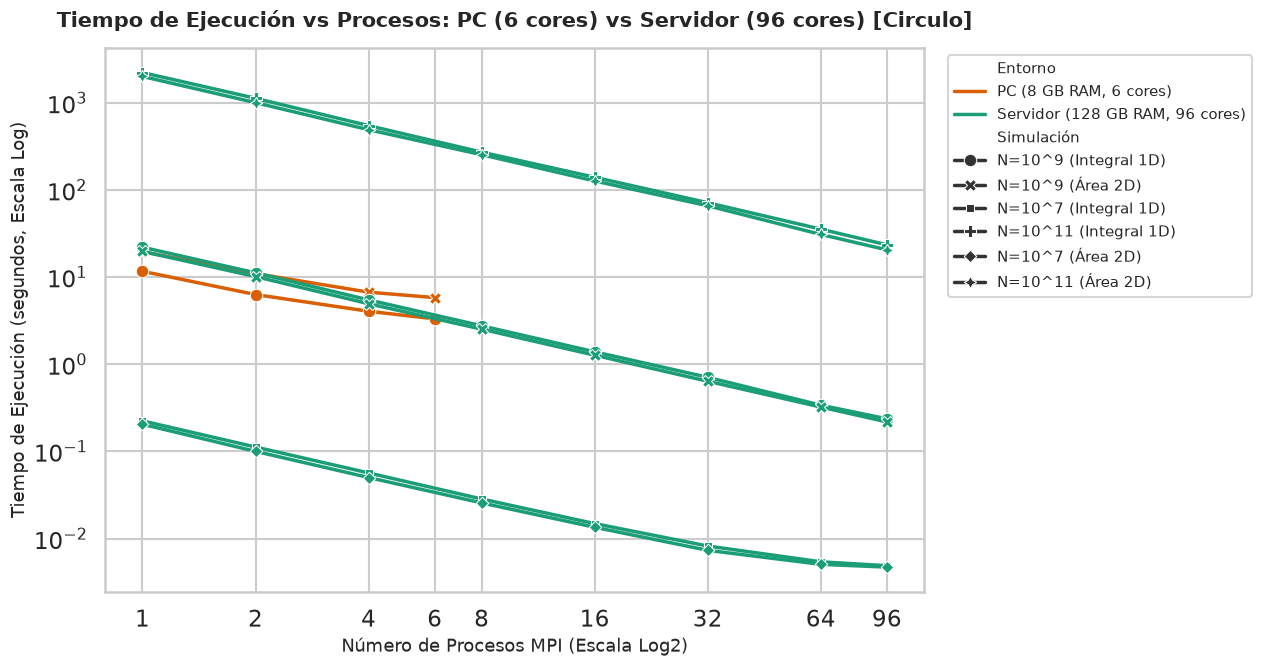

In [18]:
# Gráfica: Tiempo de Ejecución vs Procesos (PC vs Servidor)
if "df_hw" in locals() and not df_hw.empty:
    # Tomamos los tamaños grandes: 10 Millones, 1 Mil Millones y 100 Mil Millones (Servidor)
    N_filtro = [10000000, 1000000000, 100000000000]
    df_sub = df_hw[df_hw["N"].isin(N_filtro)].copy()
    df_sub["Simulación"] = df_sub.apply(lambda r: f"N={r['N_cat']} ({r['Método']})", axis=1)

    plt.figure(figsize=(13, 7))
    palette_hw = {"PC (8 GB RAM, 6 cores)": "#d95f02", "Servidor (128 GB RAM, 96 cores)": "#1b9e77"}
    
    sns.lineplot(
        data=df_sub,
        x="procesos",
        y="tiempo_segundos",
        hue="Entorno",
        style="Simulación",
        markers=True,
        dashes=False,
        markersize=9,
        linewidth=2.5,
        palette=palette_hw
    )

    plt.xscale("log", base=2)
    plt.yscale("log")
    all_p = sorted(df_hw["procesos"].unique())
    plt.xticks(all_p, labels=[str(p) for p in all_p])
    
    plt.title(f"Tiempo de Ejecución vs Procesos: PC (6 cores) vs Servidor (96 cores) [{FIGURA.capitalize()}]", fontsize=15, fontweight="bold", pad=15)
    plt.xlabel("Número de Procesos MPI (Escala Log2)", fontsize=13)
    plt.ylabel("Tiempo de Ejecución (segundos, Escala Log)", fontsize=13)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()


### 6.2. Tiempo de Ejecución vs Tamaño del Problema (N)
Comparamos cómo escala el tiempo ante el crecimiento de la carga computacional ($) evaluando cuatro regímenes de trabajo:
- **PC Local - 1 Proceso**: Línea base secuencial en la PC.
- **PC Local - 6 Procesos**: Máximo paralelismo alcanzable en la PC (6 cores físicos, 8 GB RAM).
- **Servidor HPC - 1 Proceso**: Línea base secuencial en un nodo de servidor.
- **Servidor HPC - 96 Procesos**: Máximo paralelismo alcanzable en el clúster (96 cores físicos, 128 GB RAM).


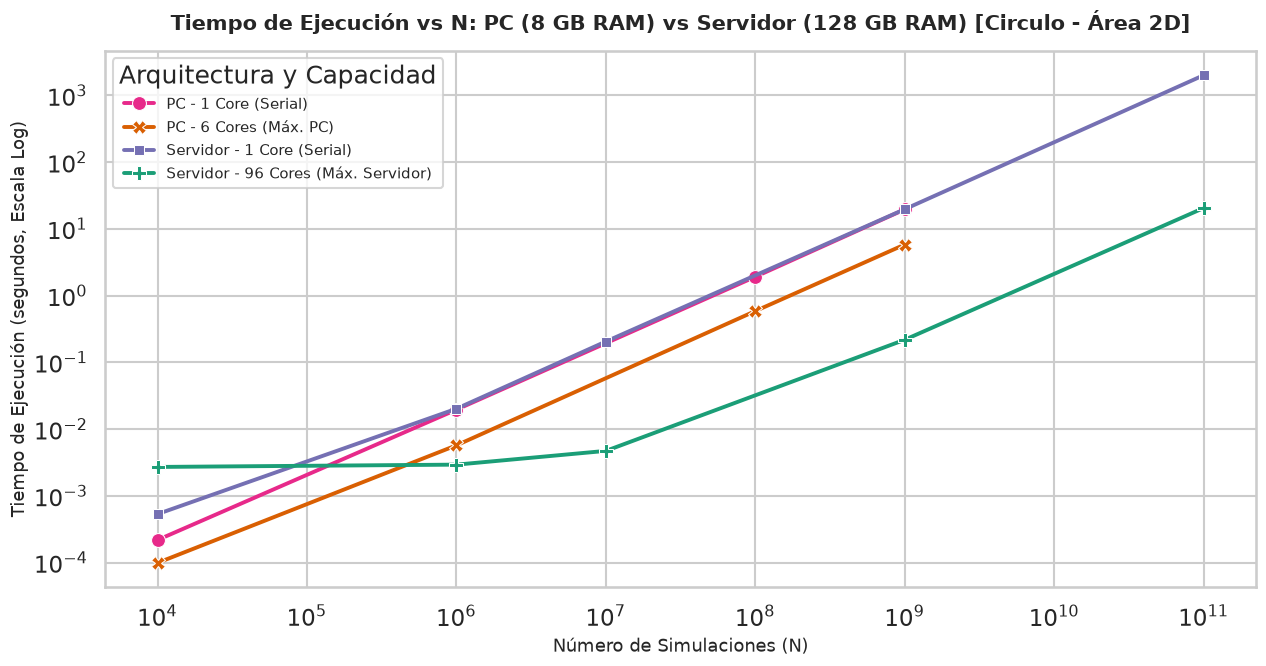

In [20]:
# Gráfica: Tiempo de Ejecución vs N (PC vs Servidor)
if "df_hw" in locals() and not df_hw.empty:
    cond_pc_1 = (df_hw["Entorno"].str.contains("PC")) & (df_hw["procesos"] == 1)
    cond_pc_max = (df_hw["Entorno"].str.contains("PC")) & (df_hw["procesos"] == 6)
    cond_srv_1 = (df_hw["Entorno"].str.contains("Servidor")) & (df_hw["procesos"] == 1)
    cond_srv_max = (df_hw["Entorno"].str.contains("Servidor")) & (df_hw["procesos"] == 96)
    
    df_regimenes = df_hw[cond_pc_1 | cond_pc_max | cond_srv_1 | cond_srv_max].copy()
    
    def etiquetar_regimen(row):
        if "PC" in row["Entorno"] and row["procesos"] == 1:
            return "PC - 1 Core (Serial)"
        elif "PC" in row["Entorno"] and row["procesos"] == 6:
            return "PC - 6 Cores (Máx. PC)"
        elif "Servidor" in row["Entorno"] and row["procesos"] == 1:
            return "Servidor - 1 Core (Serial)"
        else:
            return "Servidor - 96 Cores (Máx. Servidor)"
            
    df_regimenes["Régimen"] = df_regimenes.apply(etiquetar_regimen, axis=1)
    
    # Filtramos por Área 2D (o el método que prefieras comparar)
    df_plot_n = df_regimenes[df_regimenes["Método"] == "Área 2D"]
    
    plt.figure(figsize=(13, 7))
    paleta_regimen = {
        "PC - 1 Core (Serial)": "#e7298a",
        "PC - 6 Cores (Máx. PC)": "#d95f02",
        "Servidor - 1 Core (Serial)": "#7570b3",
        "Servidor - 96 Cores (Máx. Servidor)": "#1b9e77"
    }
    
    sns.lineplot(
        data=df_plot_n,
        x="N",
        y="tiempo_segundos",
        hue="Régimen",
        style="Régimen",
        markers=True,
        dashes=False,
        markersize=10,
        linewidth=2.8,
        palette=paleta_regimen
    )
    
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Tiempo de Ejecución vs N: PC (8 GB RAM) vs Servidor (128 GB RAM) [{FIGURA.capitalize()} - Área 2D]", fontsize=15, fontweight="bold", pad=15)
    plt.xlabel("Número de Simulaciones (N)", fontsize=13)
    plt.ylabel("Tiempo de Ejecución (segundos, Escala Log)", fontsize=13)
    plt.legend(title="Arquitectura y Capacidad", fontsize=11, loc="upper left")
    plt.tight_layout()
    plt.show()


### 6.3. Escalabilidad Fuerte: Speedup Comparativo (PC vs Servidor vs Ideal)
Comparamos el Speedup medido para el tamaño de problema mayor (=10^9$) entre la PC, el Servidor y la recta teórica ideal (=p$).


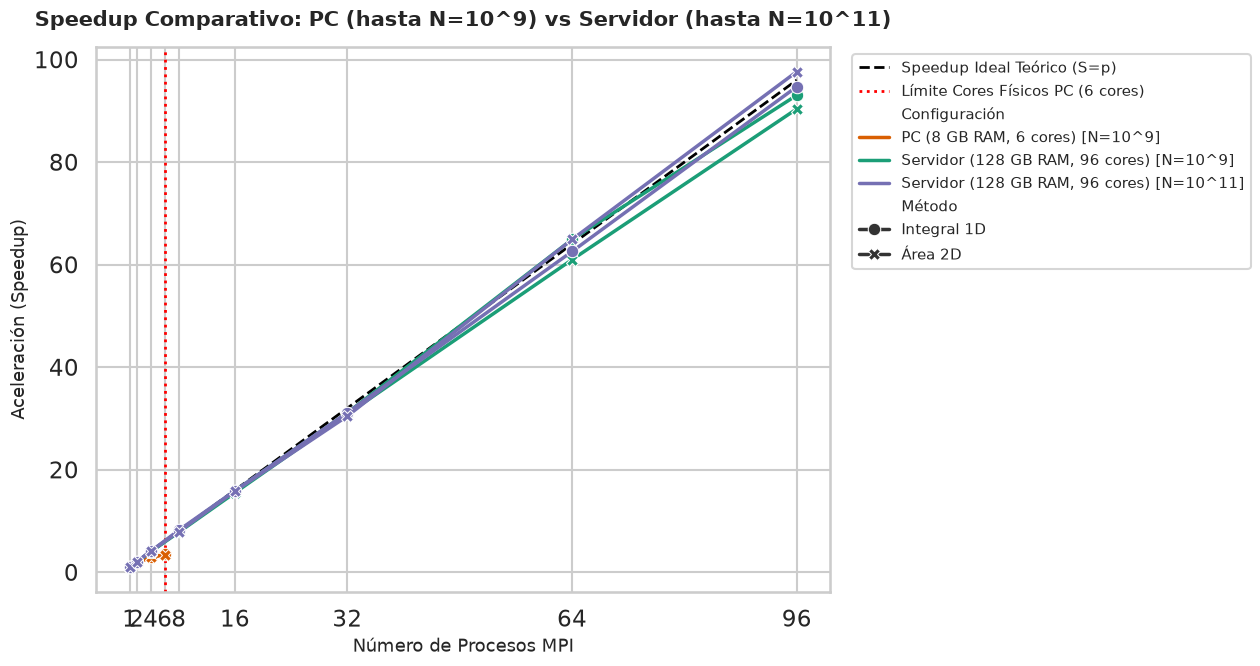

In [22]:
# Gráfica: Speedup Comparativo (PC vs Servidor vs Ideal)
if "df_hw" in locals() and not df_hw.empty:
    # Para una comparación justa, comparamos PC y Servidor en N=10^9 (máximo común),
    # e incluimos también la curva extrema de N=10^11 del Servidor si está presente.
    N_comun = 1000000000 # 1 Mil Millones
    N_extremo = 100000000000 # 100 Mil Millones
    
    cond_comun = (df_hw["N"] == N_comun)
    cond_extremo = (df_hw["Entorno"].str.contains("Servidor")) & (df_hw["N"] == N_extremo)
    
    df_speedup_comp = df_hw[cond_comun | cond_extremo].copy()
    df_speedup_comp["Configuración"] = df_speedup_comp.apply(
        lambda r: f"{r['Entorno']} [N={r['N_cat']}]", axis=1
    )
    
    plt.figure(figsize=(13, 7))
    
    # Línea ideal para la escala del servidor (96 núcleos)
    max_cores = df_speedup_comp["procesos"].max()
    plt.plot([1, max_cores], [1, max_cores], color="black", linestyle="--", linewidth=2, label="Speedup Ideal Teórico (S=p)")
    
    # Línea vertical marcando el límite físico de núcleos de la PC (6 cores)
    plt.axvline(x=6, color="red", linestyle=":", linewidth=2.0, label="Límite Cores Físicos PC (6 cores)")
    
    paleta_speedup = {
        f"PC (8 GB RAM, 6 cores) [N=10^9]": "#d95f02",
        f"Servidor (128 GB RAM, 96 cores) [N=10^9]": "#1b9e77",
        f"Servidor (128 GB RAM, 96 cores) [N=10^11]": "#7570b3"
    }
    
    sns.lineplot(
        data=df_speedup_comp,
        x="procesos",
        y="Speedup",
        hue="Configuración",
        style="Método",
        markers=True,
        dashes=False,
        markersize=9,
        linewidth=2.5,
        palette=paleta_speedup
    )
    
    plt.title(f"Speedup Comparativo: PC (hasta N=10^9) vs Servidor (hasta N=10^11)", fontsize=15, fontweight="bold", pad=15)
    plt.xlabel("Número de Procesos MPI", fontsize=13)
    plt.ylabel("Aceleración (Speedup)", fontsize=13)
    plt.xticks(sorted(df_speedup_comp["procesos"].unique()))
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()


> 🧠 **Análisis de Arquitectura y Conclusiones para la Defensa:**
> 
> 1. **Impacto de la Memoria RAM (8 GB vs 128 GB) y Ancho de Banda:**
>    - En la **PC con 8 GB de RAM**, la memoria física está compartida con el sistema operativo, los servicios de fondo y el subsistema WSL2. Al ejecutar simulaciones masivas con múltiples procesos MPI, el bus de memoria de doble canal experimenta congestión (*Memory Bandwidth Bottleneck*). Si intentáramos escalar hacia $N = 10^{10}$ o $10^{11}$, la PC sufriría degradación por *swapping* o caídas por memoria insuficiente (*Out-of-Memory*).
>    - En el **Servidor con 128 GB de RAM**, la arquitectura multicanal (típicamente 8 canales por socket) junto a memorias caché L3 masivas permiten que hasta 96 procesos generen millones de números pseudoaleatorios y acumulen datos en registros sin saturar el bus principal de memoria.
> 
> 2. **Impacto de los Cores (6 vs 96 Cores) y Ley de Amdahl:**
>    - En la **PC**, el límite físico de 6 núcleos acota el speedup teórico a un máximo de **6x**. Debido a la contención de recursos y disipación térmica, el speedup real se estabiliza alrededor de **3.4x - 3.5x**.
>    - En el **Servidor**, los 96 núcleos permiten que el algoritmo de Monte Carlo (al ser *Embarrassingly Parallel*) mantenga una aceleración casi lineal para $N \ge 10^8$, reduciendo tiempos de ~20 segundos en PC a menos de 0.3 segundos en el servidor.
> 
> 3. **Comportamiento para N Pequeños ($N = 10^4$):**
>    - Para tamaños chicos de $N$, el servidor no presenta ventaja e incluso puede registrar tiempos mayores que la PC. Esto se debe al **overhead de inicialización y sincronización de MPI**: levantar y coordinar 96 procesos a través de múltiples sockets NUMA introduce más latencia que el tiempo necesario para completar el cómputo matemático puramente secuencial.
